# 01_eda.ipynb
# Exploratory Data Analysis and Model Training for Intern Performance


In [2]:
# --- Imports ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, roc_auc_score, confusion_matrix, classification_report

import joblib

# --- Load Data ---
df = pd.read_csv("intern_performance_data.csv")
df.head()

,intern_id,department,attendance_rate,task_completion_rate,avg_feedback_score,hours_per_week,final_assessment_score,interaction_level,performance_label
0,"""INT1000",Design,77.255384,86.259552,2.54,30.443851,80.101524,High,0
1,"""INT1001",Finance,81.136955,75.112823,4.80,38.728455,79.447193,Medium,1
2,"""INT1002",Marketing,100.000000,100.000000,3.59,28.727688,97.023866,Low,1
3,"""INT1003",Finance,77.326192,87.980433,2.83,33.142919,100.000000,Medium,0
4,"""INT1004",Finance,84.222273,81.868861,4.81,38.796929,87.738883,Medium,1


#basic exploration


In [3]:
# Shape and info
print("Shape:", df.shape)
df.info()

# Summary statistics
df.describe()

# Class distribution
df['performance_label'].value_counts()

Shape: (10000, 9)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 9 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   intern_id               10000 non-null  object 
 1   department              10000 non-null  object 
 2   attendance_rate         10000 non-null  float64
 3   task_completion_rate    10000 non-null  float64
 4   avg_feedback_score      10000 non-null  float64
 5   hours_per_week          10000 non-null  float64
 6   final_assessment_score  10000 non-null  float64
 7   interaction_level       10000 non-null  object 
 8   performance_label       10000 non-null  int64  
dtypes: float64(5), int64(1), object(3)
memory usage: 703.3+ KB


,count
performance_label,
0,8583
1,1417


#CORRELATION MATRIX

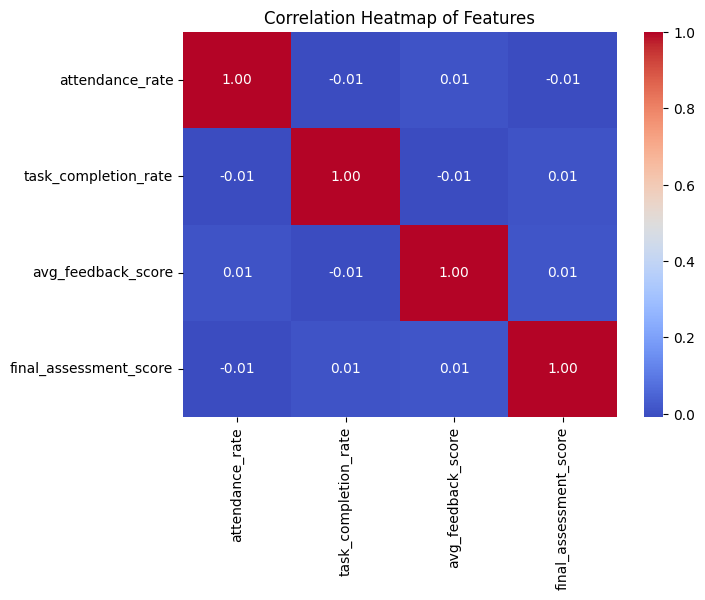

In [4]:
features = ['attendance_rate', 'task_completion_rate', 'avg_feedback_score', 'final_assessment_score']
target = 'performance_label'

plt.figure(figsize=(7,5))
sns.heatmap(df[features].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap of Features")
plt.show()

#DISTRIBUTION

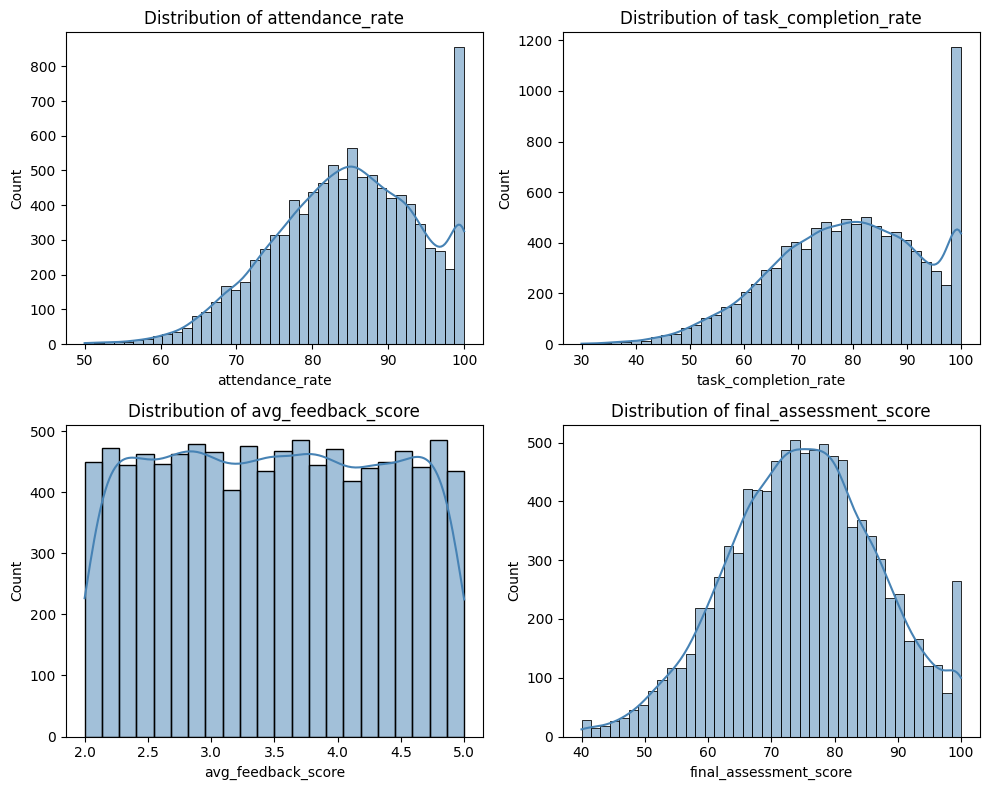

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(10,8))
axes = axes.ravel()
for i, col in enumerate(features):
    sns.histplot(df[col], kde=True, ax=axes[i], color="steelblue")
    axes[i].set_title(f"Distribution of {col}")
plt.tight_layout()
plt.show()

#PAIR PLOT

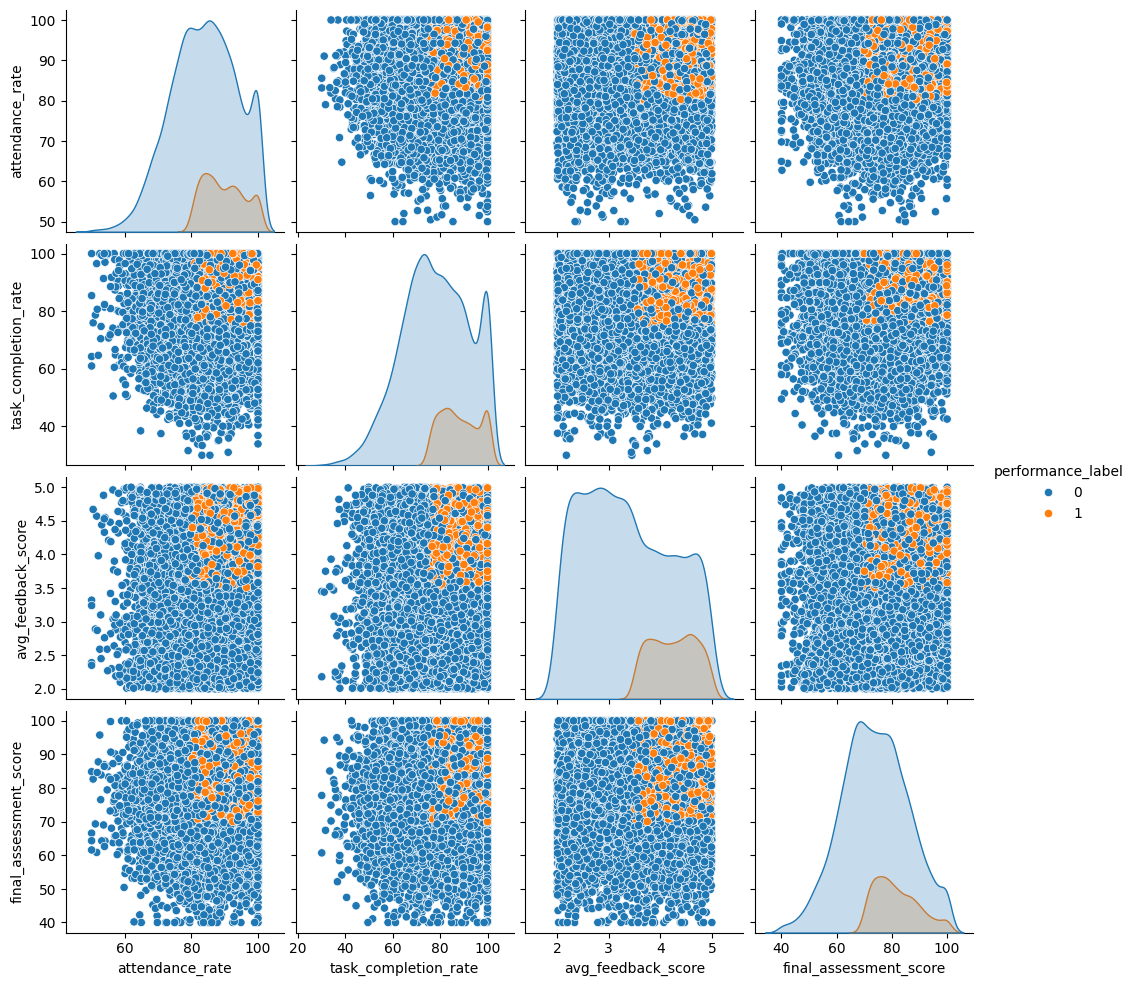

In [6]:
sns.pairplot(df[features + [target]], hue=target, diag_kind="kde")
plt.show()

# Train/Test Split + Scalin

In [7]:
X = df[features]
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

#RANDOM FOREST MODEL

In [8]:
rf = RandomForestClassifier(random_state=42, n_jobs=-1)
param_grid_rf = {
    'n_estimators': [200, 400],
    'max_depth': [None, 6, 10],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'max_features': ['sqrt', 'log2']
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
grid_rf = GridSearchCV(rf, param_grid_rf, scoring='f1', cv=cv, n_jobs=-1)
grid_rf.fit(X_train_scaled, y_train)

rf_best = grid_rf.best_estimator_
print("Best RF Params:", grid_rf.best_params_)

Best RF Params: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 200}


#XG BOOST MODEL

In [9]:
xgb = XGBClassifier(
    random_state=42,
    n_jobs=-1,
    eval_metric='logloss',
    tree_method='hist'
)

param_grid_xgb = {
    'n_estimators': [300, 500],
    'max_depth': [3, 6, 9],
    'learning_rate': [0.05, 0.1],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0],
    'reg_lambda': [1.0, 2.0]
}

grid_xgb = GridSearchCV(xgb, param_grid_xgb, scoring='f1', cv=cv, n_jobs=-1)
grid_xgb.fit(X_train_scaled, y_train)

xgb_best = grid_xgb.best_estimator_
print("Best XGB Params:", grid_xgb.best_params_)

Best XGB Params: {'colsample_bytree': 0.8, 'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 500, 'reg_lambda': 2.0, 'subsample': 0.8}


#EVALUATION FUNCTION

In [10]:
def evaluate_model(model, X_test, y_test, name="Model"):
    y_pred = model.predict(X_test)
    metrics = {
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred),
        "recall": recall_score(y_test, y_pred),
        "f1": f1_score(y_test, y_pred),
        "confusion_matrix": confusion_matrix(y_test, y_pred),
        "report": classification_report(y_test, y_pred, digits=4)
    }
    print(f"\n{name} Evaluation:")
    for k,v in metrics.items():
        if k not in ["confusion_matrix","report"]:
            print(f"{k}: {v:.4f}")
    print("Confusion Matrix:\n", metrics["confusion_matrix"])
    print("Classification Report:\n", metrics["report"])
    return metrics

rf_metrics = evaluate_model(rf_best, X_test_scaled, y_test, "Random Forest")
xgb_metrics = evaluate_model(xgb_best, X_test_scaled, y_test, "XGBoost")


Random Forest Evaluation:
accuracy: 1.0000
precision: 1.0000
recall: 1.0000
f1: 1.0000
Confusion Matrix:
 [[1717    0]
 [   0  283]]
Classification Report:
               precision    recall  f1-score   support

           0     1.0000    1.0000    1.0000      1717
           1     1.0000    1.0000    1.0000       283

    accuracy                         1.0000      2000
   macro avg     1.0000    1.0000    1.0000      2000
weighted avg     1.0000    1.0000    1.0000      2000


XGBoost Evaluation:
accuracy: 1.0000
precision: 1.0000
recall: 1.0000
f1: 1.0000
Confusion Matrix:
 [[1717    0]
 [   0  283]]
Classification Report:
               precision    recall  f1-score   support

           0     1.0000    1.0000    1.0000      1717
           1     1.0000    1.0000    1.0000       283

    accuracy                         1.0000      2000
   macro avg     1.0000    1.0000    1.0000      2000
weighted avg     1.0000    1.0000    1.0000      2000



#FEATURE IMPORTANCE

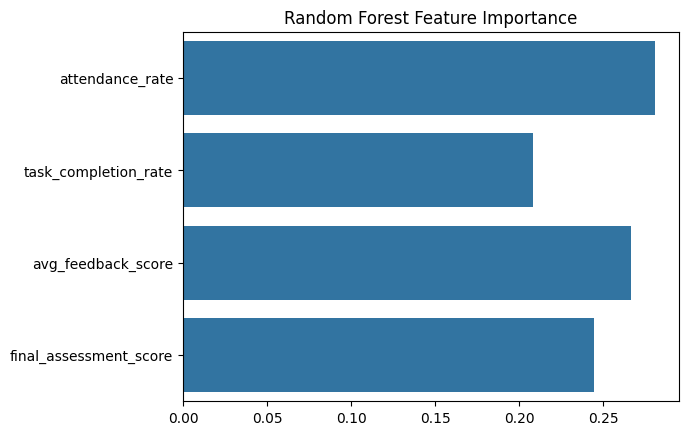

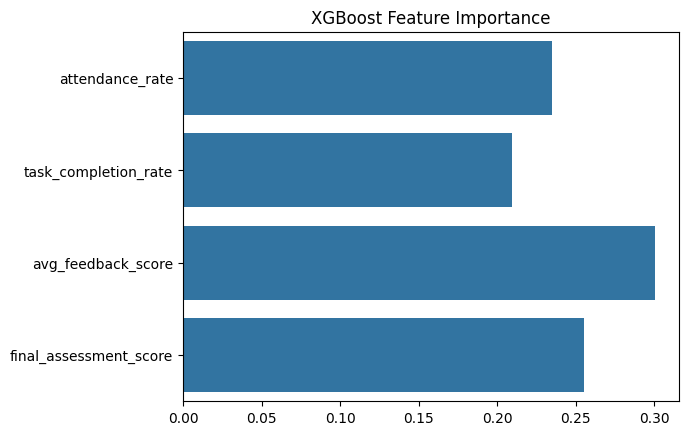

In [11]:
# Random Forest
importances_rf = rf_best.feature_importances_
sns.barplot(x=importances_rf, y=features)
plt.title("Random Forest Feature Importance")
plt.show()

# XGBoost
importances_xgb = xgb_best.feature_importances_
sns.barplot(x=importances_xgb, y=features)
plt.title("XGBoost Feature Importance")
plt.show()

#CONFUSION MATRIX

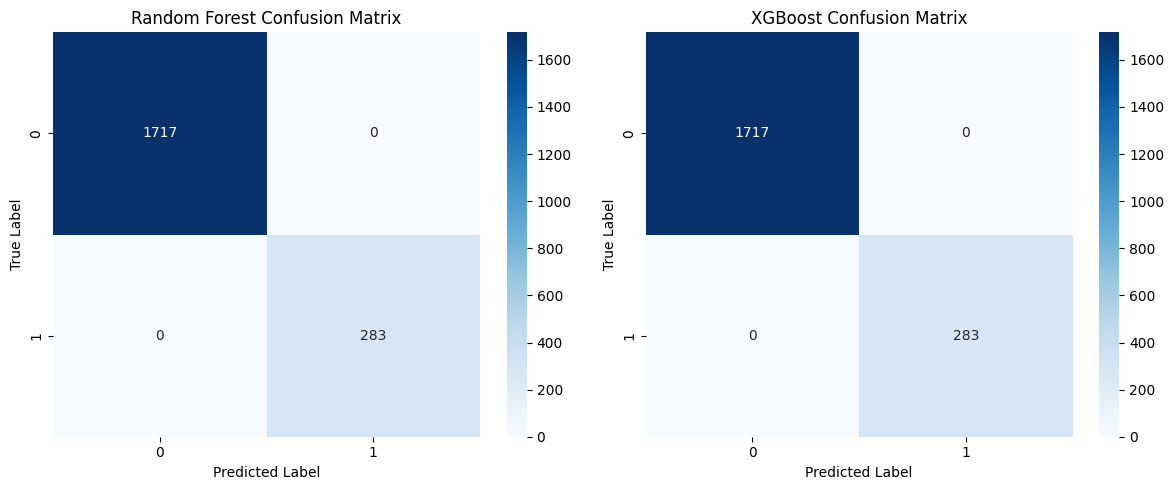

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Plot Random Forest Confusion Matrix
sns.heatmap(rf_metrics["confusion_matrix"], annot=True, fmt="d", cmap="Blues", ax=axes[0])
axes[0].set_title("Random Forest Confusion Matrix")
axes[0].set_xlabel("Predicted Label")
axes[0].set_ylabel("True Label")

# Plot XGBoost Confusion Matrix
sns.heatmap(xgb_metrics["confusion_matrix"], annot=True, fmt="d", cmap="Blues", ax=axes[1])
axes[1].set_title("XGBoost Confusion Matrix")
axes[1].set_xlabel("Predicted Label")
axes[1].set_ylabel("True Label")

plt.tight_layout()
plt.show()

#SAVE MODEL


In [ ]:
joblib.dump(rf_best, "models/rf_best.pkl")
joblib.dump(xgb_best, "models/xgb_best.pkl")

In [14]:
# Compare F1 scores (or any metric you prefer)
rf_f1 = rf_metrics["f1"]
xgb_f1 = xgb_metrics["f1"]

print("\nModel Comparison:")
print(f"Random Forest F1 Score: {rf_f1:.4f}")
print(f"XGBoost F1 Score: {xgb_f1:.4f}")

if xgb_f1 > rf_f1:
    print("🏆 Verdict: XGBoost performed better based on F1 score.")
elif rf_f1 > xgb_f1:
    print("🏆 Verdict: Random Forest performed better based on F1 score.")
else:
    print("🤝 Verdict: Both models performed equally well.")


Model Comparison:
Random Forest F1 Score: 1.0000
XGBoost F1 Score: 1.0000
🤝 Verdict: Both models performed equally well.
